# Assignment 1

## *How should I price auto insurance in the United States?*

## Introduction

**Business Context.** The ability to price an insurance quote properly has a significant impact on insurers' management decisions and financial statements. You are the chief data scientist at a new startup insurance company focusing on providing affordable insurance to millennials. You are tasked to assess the current state of insurance companies to see what factors large insurance providers charge premiums for. Fortunately for you, your company has compiled a dataset by surveying what people currently pay for insurance from large companies. Your findings will be used as the basis of developing your company's millenial car insurance offering. 

**Business Problem.** Your task is to build a **minimal** model to predict the cost of insurance from the data set using various characteristics of a policyholder.

**Analytical Context.** The data resides in a CSV file which has been pre-cleaned for you and can directly be read in. Throughout the case, you will be iterating on your initial model many times based on common pitfalls that arise which we discussed in previous cases. You will be using the Python `statsmodels` package to create and analyze these linear models.

In [6]:
### Load relevant packages

import pandas                  as pd
import numpy                   as np
import matplotlib.pyplot       as plt
import seaborn                 as sns
import statsmodels.api         as sm
import statsmodels.formula.api as smf
import os
from sklearn.model_selection import train_test_split
import scipy.stats as stats

# This statement allow to display plot without asking to 
%matplotlib inline

# always make it pretty 
plt.style.use('ggplot')

## Diving into the data

In [8]:
df = pd.read_csv('Allstate-cost-cleaned.csv',
    dtype = { # indicate categorical variables
        'A': 'category',
        'B': 'category',
        'C': 'category',
        'D': 'category',
        'E': 'category',
        'F': 'category',
        'G': 'category',
        'car_value': 'category',
        'state': 'category'
    }
)

The following are the columns in the dataset:

1. **state**: State where shopping point occurred
2. **group_size**: How many people will be covered under the policy (1, 2, 3 or 4) 
3. **homeowner**: Whether the customer owns a home (0=no, 1=yes)
4. **car_age**: Age of the customer's car (How old the car is)
5. **car_value**: Value of the car when it was new
6. **risk_factor**: An ordinal assessment of how risky the customer is (0,1, 2, 3, 4) 
7. **age_oldest**: Age of the oldest person in customer's group
8. **age_youngest**: Age of the youngest person in customer's group
9. **married_couple**: Does the customer group contain a married couple (0=no, 1=yes) 
10. **C_previous**: What the customer formerly had or currently has for product option C (0=nothing, 1, 2, 3,4)
11. **duration_previous**: How long (in years) the customer was covered by their previous issuer
12. **A,B,C,D,E,F,G**: The coverage options:
13. **A**: Collision (levels: 0, 1, 2);
14. **B**: Towing (levels: 0, 1);
15. **C**: Bodily Injury (BI, levels: 1, 2, 3, 4);
16. **D**: Property Damage (PD, levels 1, 2, 3);
17. **E**: Rental Reimbursement (RR, levels: 0, 1);
18. **F**: Comprehensive (Comp, levels: 0, 1, 2, 3);
19. **G**: Medical/Personal Injury Protection (Med/PIP, levels: 1, 2, 3, 4)
20. **cost**: cost of the quoted coverage options 

In [10]:
df.head(10)

,Unnamed: 0,state,group_size,homeowner,car_age,car_value,risk_factor,age_oldest,age_youngest,married_couple,C_previous,duration_previous,A,B,C,D,E,F,G,cost
0,0,OK,1,0,9,f,0.0,24,24,0,3.0,9.0,0,0,1,1,0,0,4,543
1,1,OK,1,0,9,f,0.0,24,24,0,3.0,9.0,2,1,1,3,1,3,2,611
2,2,PA,1,1,7,f,0.0,74,74,0,2.0,15.0,2,0,2,3,1,2,2,691
3,3,PA,1,1,7,f,0.0,74,74,0,2.0,15.0,2,0,2,3,1,2,2,695
4,4,AR,1,0,4,d,4.0,26,26,0,3.0,1.0,1,0,1,1,0,2,2,628
5,5,AR,1,0,4,d,4.0,26,26,0,3.0,1.0,1,0,2,1,0,2,2,625
6,6,AR,1,0,4,d,4.0,26,26,0,3.0,1.0,1,0,2,1,0,2,2,628
7,7,OK,1,0,13,f,3.0,22,22,0,0.0,0.0,0,0,1,1,0,0,2,596
8,8,OK,1,0,13,f,3.0,22,22,0,0.0,0.0,2,0,1,1,0,3,2,711
9,9,OK,1,0,13,f,3.0,22,22,0,0.0,0.0,2,0,1,1,0,3,2,722


### Exercise 1:

Write code to visualize the relationship between cost and the following variables. Choose your plots judiciously based on what you know about each variable. Different variable types (categorical vs. numerical) should have different types of plots (e.g. scatter, boxplot, violin plot, etc.) Group your plots together using the `plt.subplot()` function.

1. `car_age`
2. `age_oldest`
3. `age_youngest`
4. `duration_previous`
5. `C_previous`
6. `homeowner`
7. `group_size`
8. `car_age`
9. Categories A-G (7 different plots)

**Answer.**

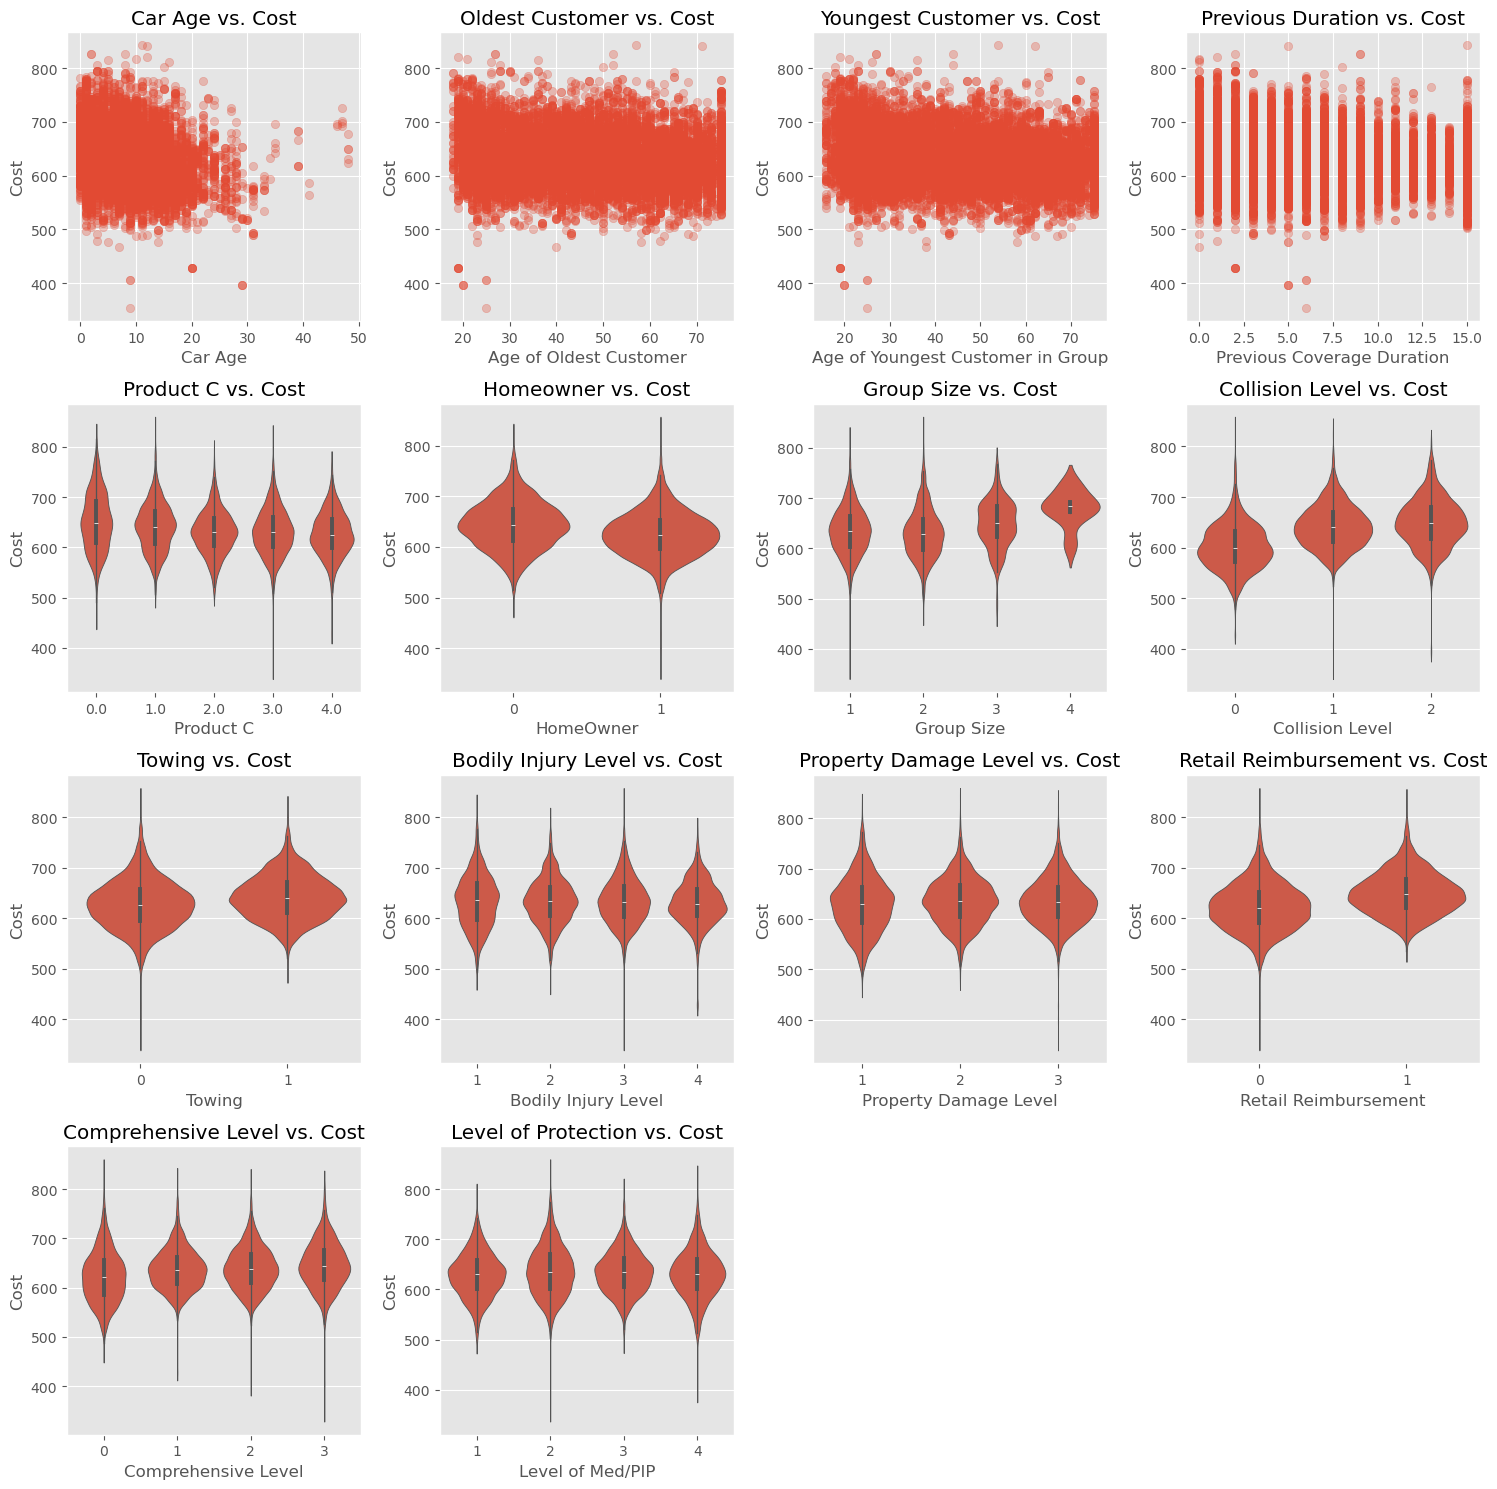

In [13]:
#Probably did very wrong, run through - how to do bar plots?
fig, axes = plt.subplots(4,4, figsize=(15,15))


#car age variable
axes[0,0].scatter(df['car_age'], df['cost'], marker='o', alpha = 0.3)

axes[0,0].set_xlabel('Car Age')
axes[0,0].set_ylabel('Cost')
axes[0,0].set_title('Car Age vs. Cost')

# age_oldest variable 
axes[0,1].scatter(df['age_oldest'], df['cost'], marker='o', alpha = 0.3)

axes[0,1].set_xlabel('Age of Oldest Customer')
axes[0,1].set_ylabel('Cost')
axes[0,1].set_title('Oldest Customer vs. Cost')

# age_youngest variable
axes[0,2].scatter(df['age_youngest'], df['cost'], marker='o', alpha = 0.3)

axes[0,2].set_xlabel('Age of Youngest Customer in Group')
axes[0,2].set_ylabel('Cost')
axes[0,2].set_title('Youngest Customer vs. Cost')
#duration_previous variable 
axes[0,3].scatter(df['duration_previous'], df['cost'], marker='o', alpha = 0.3)

axes[0,3].set_xlabel('Previous Coverage Duration')
axes[0,3].set_ylabel('Cost')
axes[0,3].set_title('Previous Duration vs. Cost')

#C_previous variable 
sns.violinplot(x = 'C_previous',y ='cost', data = df, ax = axes[1,0])
axes[1,0].set_xlabel('Product C')
axes[1,0].set_ylabel('Cost')
axes[1,0].set_title('Product C vs. Cost')

#homeowner variable
sns.violinplot(x = 'homeowner',y ='cost', data = df, ax = axes[1,1])
axes[1,1].set_xlabel('HomeOwner')
axes[1,1].set_ylabel('Cost')
axes[1,1].set_title('Homeowner vs. Cost')

#group_size variable 
sns.violinplot(x = 'group_size',y ='cost', data = df, ax = axes[1,2])
axes[1,2].set_xlabel('Group Size')
axes[1,2].set_ylabel('Cost')
axes[1,2].set_title('Group Size vs. Cost')

#Category A
sns.violinplot(x = 'A',y ='cost', data = df, ax = axes[1,3])
axes[1,3].set_xlabel('Collision Level')
axes[1,3].set_ylabel('Cost')
axes[1,3].set_title('Collision Level vs. Cost')

#Category B
sns.violinplot(x = 'B',y ='cost', data = df, ax = axes[2,0])
axes[2,0].set_xlabel('Towing')
axes[2,0].set_ylabel('Cost')
axes[2,0].set_title('Towing vs. Cost')

#Category C
sns.violinplot(x = 'C',y ='cost', data = df, ax = axes[2,1])
axes[2,1].set_xlabel('Bodily Injury Level')
axes[2,1].set_ylabel('Cost')
axes[2,1].set_title('Bodily Injury Level vs. Cost')

#Category D
sns.violinplot(x = 'D',y ='cost', data = df, ax = axes[2,2])
axes[2,2].set_xlabel('Property Damage Level')
axes[2,2].set_ylabel('Cost')
axes[2,2].set_title('Property Damage Level vs. Cost')

#Category E
sns.violinplot(x = 'E',y ='cost', data = df, ax = axes[2,3])
axes[2,3].set_xlabel('Retail Reimbursement')
axes[2,3].set_ylabel('Cost')
axes[2,3].set_title('Retail Reimbursement vs. Cost')

#Category F

sns.violinplot(x = 'F',y ='cost', data = df, ax = axes[3,0])
axes[3,0].set_xlabel('Comprehensive Level')
axes[3,0].set_ylabel('Cost')
axes[3,0].set_title('Comprehensive Level vs. Cost')

#Category G
sns.violinplot(x = 'G',y ='cost', data = df, ax = axes[3,1])
axes[3,1].set_xlabel('Level of Med/PIP')
axes[3,1].set_ylabel('Cost')
axes[3,1].set_title('Level of Protection vs. Cost')

axes = axes.flatten()
for j in range(14, len(axes)):  # Start from the first unused index
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


----------

### Exercise 2:

Convert all categorical data to be in the one-hot encoding format.

**Answer.**

In [17]:
#Categorical variables include categories A-G, State and car value

encoded_df = pd.get_dummies(df, columns =['state', 'car_value', 'A', 'B', 'C', 'D', 'E', 'F','G'], drop_first = True)
encoded_df.columns

Index(['Unnamed: 0', 'group_size', 'homeowner', 'car_age', 'risk_factor',
       'age_oldest', 'age_youngest', 'married_couple', 'C_previous',
       'duration_previous', 'cost', 'state_AR', 'state_CO', 'state_CT',
       'state_DC', 'state_DE', 'state_FL', 'state_GA', 'state_IA', 'state_ID',
       'state_IN', 'state_KS', 'state_KY', 'state_MD', 'state_ME', 'state_MO',
       'state_MS', 'state_MT', 'state_ND', 'state_NE', 'state_NH', 'state_NM',
       'state_NV', 'state_NY', 'state_OH', 'state_OK', 'state_OR', 'state_PA',
       'state_RI', 'state_SD', 'state_TN', 'state_UT', 'state_WA', 'state_WI',
       'state_WV', 'state_WY', 'car_value_b', 'car_value_c', 'car_value_d',
       'car_value_e', 'car_value_f', 'car_value_g', 'car_value_h',
       'car_value_i', 'A_1', 'A_2', 'B_1', 'C_2', 'C_3', 'C_4', 'D_2', 'D_3',
       'E_1', 'F_1', 'F_2', 'F_3', 'G_2', 'G_3', 'G_4'],
      dtype='object')

----------

## Fitting a multiple linear regression

### Exercise 3:

Split your data into training and testing sets (an 80-20 split is a good starting point).

**Note:** Keep random seed as 1337 in the code cell

**Answer.**

In [22]:
#Target variable for model - Cost
x = encoded_df.drop(columns=['cost'])
y = encoded_df['cost']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 1337)

----------

### Exercise 4:

#### 4.1

Fit a multiple linear regression model to the training data regressing cost against all the other variables. Call this `model_all`. What is the AIC value?

**Answer.**

In [26]:
#Joining training data into one dataframe for easy manipulation
training_data = x_train.copy()
training_data['cost'] = y_train
training_data.head()

,Unnamed: 0,group_size,homeowner,car_age,risk_factor,age_oldest,age_youngest,married_couple,C_previous,duration_previous,...,D_2,D_3,E_1,F_1,F_2,F_3,G_2,G_3,G_4,cost
10346,10346,2,1,3,1.0,69,68,1,4.0,15.0,...,False,True,True,False,True,False,False,True,False,581
6668,6668,1,0,39,0.0,71,71,0,2.0,15.0,...,True,False,True,False,True,False,False,False,False,667
13433,13433,1,0,10,4.0,30,30,0,1.0,2.0,...,False,False,False,False,False,False,False,False,False,625
8614,8614,1,1,9,4.0,26,26,0,0.0,0.0,...,True,False,False,False,True,False,True,False,False,672
240,240,1,0,6,0.0,23,23,0,3.0,8.0,...,False,True,False,True,False,False,False,False,False,679


In [27]:
training_data.columns

Index(['Unnamed: 0', 'group_size', 'homeowner', 'car_age', 'risk_factor',
       'age_oldest', 'age_youngest', 'married_couple', 'C_previous',
       'duration_previous', 'state_AR', 'state_CO', 'state_CT', 'state_DC',
       'state_DE', 'state_FL', 'state_GA', 'state_IA', 'state_ID', 'state_IN',
       'state_KS', 'state_KY', 'state_MD', 'state_ME', 'state_MO', 'state_MS',
       'state_MT', 'state_ND', 'state_NE', 'state_NH', 'state_NM', 'state_NV',
       'state_NY', 'state_OH', 'state_OK', 'state_OR', 'state_PA', 'state_RI',
       'state_SD', 'state_TN', 'state_UT', 'state_WA', 'state_WI', 'state_WV',
       'state_WY', 'car_value_b', 'car_value_c', 'car_value_d', 'car_value_e',
       'car_value_f', 'car_value_g', 'car_value_h', 'car_value_i', 'A_1',
       'A_2', 'B_1', 'C_2', 'C_3', 'C_4', 'D_2', 'D_3', 'E_1', 'F_1', 'F_2',
       'F_3', 'G_2', 'G_3', 'G_4', 'cost'],
      dtype='object')

In [28]:
model_all = smf.ols(formula=('cost ~ group_size+ homeowner+ car_age + risk_factor+ age_oldest+ ' 
                            'age_youngest+ married_couple+ C_previous+ duration_previous + '
                             'state_AR + state_CO + state_CT + state_DC + state_DE + state_FL +'
                             'state_GA + state_IA + state_ID + state_IN + state_KS + state_KY + '
                             'state_MD + state_ME + state_MO + state_MS + state_MT + state_ND + state_NE + '
                             ' state_NH + state_NM + state_NV + state_NY + state_OH + state_OK + state_OR +'
                             'state_PA + state_RI + state_SD + state_TN + state_UT + state_WA +'
                             ' state_WI + state_WV + state_WY + car_value_b + car_value_c + car_value_d + '
                             'car_value_e + car_value_f + car_value_g + car_value_h+ car_value_i + A_1 + ' 
                             'A_2 + B_1 + C_2 + C_3 + C_4 + D_2 + D_3 + E_1 + F_1 + F_2 + F_3 + G_2 + G_3 + G_4'
                            ),data = training_data).fit()
print(model_all.summary())

                            OLS Regression Results                            
Dep. Variable:                   cost   R-squared:                       0.436
Model:                            OLS   Adj. R-squared:                  0.432
Method:                 Least Squares   F-statistic:                     141.8
Date:                Fri, 07 Feb 2025   Prob (F-statistic):               0.00
Time:                        15:44:02   Log-Likelihood:                -61793.
No. Observations:               12386   AIC:                         1.237e+05
Df Residuals:                   12318   BIC:                         1.242e+05
Df Model:                          67                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept             678.9815    

In [29]:
value = model_all.aic
print("The AIC value of model_all is " + str(value))

The AIC value of model_all is 123722.40754777443


----------

#### 4.2 

According to `model_all`, which states are most and least expensive?

**Answer.**

To find the states that are the most expensive, we can look at the largest coefficients in the summary table - specifically in the rows corresponding to the states. 
The three most expensive states are the following:
- State DC (41.2959 coeff) - Predicted cost: 720.2774
- State DE (39.8354 coeff) - Predicted cost: 718.8169
- State NY (38.4059 coeff) - Predicted cost: 717.3874

Similarly, to find the states that are the least expensive, we can look at the smallest coefficients in the summary table - specifically in the rows corresponding to the states. 
The three least expensive states are the following: 
- State IA (-49.6236 coeff) - Predicted cost: 629.3579
- State ME (-34.4240 coeff) - Predicted cost: 644.5575
- State WI (-32.7110 coeff) - Predicted cost: 646.2705

----------

#### 4.3

Interpret the coefficients of `group_size`, `homeowner`, `car_age`, `risk_factor`, `age_oldest`, `age_youngest`       `married_couple` , `duration_previous`. Do the signs and values of these coefficients make sense to you in the context of this business problem?

**Answer.**

The coefficients of each variable suggests the increase in cost for an increase of one unit in the variable. An increase in one unit for each variable can be defined in the following way:
- group_size: adding an additional person to insurance policy 
- homeowner: Someone in policy being a homeowner
- car_age: Increase in age of customer's car (older car)
- risk_factor: Increase in riskiness of customer
- age_oldest: Increase in age of oldest person in policies 
- age_youngest: Increase in age of youngest customer in policies
- married_couple: Having a married couple in the policy
- duration_previous: Increase in number of years at last insurance policy company

- The group size coefficient is 2.8220. This does not make much sense as this would imply that adding someone into the insurance policy only costs an additional $2.82. In reality, adding an additional person to an insurance policy is much more expensive.
- The homeowner coefficient is -14.1096. This implies that homeowners pay a lower cost for their insurance policy than renters (non-homeowners). This makes some sense as cars are less likely to be damaged if the individual owns a home/may have a garage to keep their car in (less chance of being vandalized/broken into). The 'discount' is very little on the insurance policy - I would imagine it would be higher - but there may be other factors impacting the price (e.x Where the person lives, urban areas, etc).
- The car age coefficient is -0.7839. This implies that as a car gets older, the policy becomes cheaper. This makes some sense, since older cars are less prone to being vandalised and parts may be cheaper to replace. I would expect the 'discount' for each year would be greater, not merely a difference of 78 cents. 
- The risk factor coefficient is -0.7263. This does not make sense at all. This implies that the more risky an individual is, the policy would cost less. In reality, the policy should be exponentially more expensive.
- The age_oldest coefficient is 0.5646. This implies that as that if the oldest person in the policy is older, the policy is more expensive. This does not make much sense when looking at this isolated factor. This may make more sense when looking at other factors.  
- The age_youngest coefficient is -0.9566. This makes some sense as this implies that the youngest person in the plan is older. In other words, the people covered in the policy are older. To the business, younger individuals are more inexperienced and reckless while driving, making them cost more to insure. Thus, if everyone in the policy is older, the plan should be less expensive. Again, I would think that the value difference would be larger than merly 96 cents.
- The married couple coefficient is -9.7020. This makes some sense as this implies that if a married couple is covered in the plan, the plan will be cheaper. To a business, they view married couples as reliable and safe. Since they have a loved one/spouse, they are less likely to be reckless and be more cautious while driving. This would make the policy cheaper.
- The duration previous coefficient is -1.4821. This implies that if a customer had a longer policy at the previous company, the cheaper the new policy (at this business) would be. This makes sense from a business perspective as the business is trying to attract new loyal customers. In order to attract them, this business would have to offer a discounted policy (better than any other deal available at any other autoinsurance business). 


Overall, the coefficient for risk factor makes 0 sense. The other coefficients for the other variables make some sense, but I would expect the (absolute) values of the coefficients to be larger. 

----------

### Exercise 5:

Which variables from `model_all` are statistically significant? (For categorical variables, consider them to be significant if at least one of their categories are statistically significant). Refit the model using only these variables; call this `model_sig`. How does this model compare to the previous model?

**Answer.**

In [41]:
#A variable is statistically significant,if the p-value is < 0.05 (observe P > |t| column)
# The variables we will remove include 'groupsize' and 'D'. 
model_sig = smf.ols(formula=('cost ~ homeowner+ car_age + risk_factor+ age_oldest+ ' 
                            'age_youngest+ married_couple+ C_previous+ duration_previous + '
                             'state_AR + state_CO + state_CT + state_DC + state_DE + state_FL +'
                             'state_GA + state_IA + state_ID + state_IN + state_KS + state_KY + '
                             'state_MD + state_ME + state_MO + state_MS + state_MT + state_ND + state_NE + '
                             ' state_NH + state_NM + state_NV + state_NY + state_OH + state_OK + state_OR +'
                             'state_PA + state_RI + state_SD + state_TN + state_UT + state_WA +'
                             ' state_WI + state_WV + state_WY + car_value_b + car_value_c + car_value_d + '
                             'car_value_e + car_value_f + car_value_g + car_value_h+ car_value_i + A_1 + ' 
                             'A_2 + B_1 + C_2 + C_3 + C_4 + E_1 + F_1 + F_2 + F_3 + G_2 + G_3 + G_4'
                            ),data = training_data).fit()
print(model_sig.summary())

                            OLS Regression Results                            
Dep. Variable:                   cost   R-squared:                       0.435
Model:                            OLS   Adj. R-squared:                  0.432
Method:                 Least Squares   F-statistic:                     148.3
Date:                Fri, 07 Feb 2025   Prob (F-statistic):               0.00
Time:                        15:44:02   Log-Likelihood:                -61797.
No. Observations:               12386   AIC:                         1.237e+05
Df Residuals:                   12321   BIC:                         1.242e+05
Df Model:                          64                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept             681.4666    

We have removed two variables (variable D and variable group size) from the original "model_all" model since we observed that their p-values were greater than 0.05. After refitting the model, we do not see much of an improvement in the model (compared to model_all) as the R-squared and AIC values are almost identical. 

----------

### Exercise 6:

In addition to the variables in `model_sig`, add terms for:

1. square of `age_youngest`
2. square term for the age of the car
3. interaction term for `car_value` and `age_youngest`

and save it to a new model `model_sig_plus`.

**Answer.**

In [46]:
model_sig_plus = smf.ols(formula=('cost ~ homeowner+ risk_factor+ age_oldest+ car_age + age_youngest+ ' 
                                  'married_couple+ C_previous+ duration_previous + '
                                  'state_AR + state_CO + state_CT + state_DC + state_DE + state_FL +'
                                  'state_GA + state_IA + state_ID + state_IN + state_KS + state_KY + '
                                  'state_MD + state_ME + state_MO + state_MS + state_MT + state_ND + state_NE + '
                                  ' state_NH + state_NM + state_NV + state_NY + state_OH + state_OK + state_OR +'
                                  'state_PA + state_RI + state_SD + state_TN + state_UT + state_WA +'
                                  'state_WI + state_WV + state_WY + car_value_b + car_value_c + car_value_d + '
                                  'car_value_e + car_value_f + car_value_g + car_value_h+ car_value_i + A_1 + ' 
                                  'A_2 + B_1 + C_2 + C_3 + C_4 + E_1 + F_1 + F_2 + F_3 + G_2 + G_3 + G_4+ '
                                  'I(age_youngest **2) + I(car_age **2) + car_value_b *age_youngest + car_value_c *age_youngest +'
                                  'car_value_d *age_youngest + car_value_e *age_youngest + car_value_f *age_youngest + '
                                  'car_value_g *age_youngest + car_value_h *age_youngest'
                                 ),data = training_data).fit()
print(model_sig_plus.summary())

                            OLS Regression Results                            
Dep. Variable:                   cost   R-squared:                       0.452
Model:                            OLS   Adj. R-squared:                  0.448
Method:                 Least Squares   F-statistic:                     138.9
Date:                Fri, 07 Feb 2025   Prob (F-statistic):               0.00
Time:                        15:44:02   Log-Likelihood:                -61613.
No. Observations:               12386   AIC:                         1.234e+05
Df Residuals:                   12312   BIC:                         1.239e+05
Df Model:                          73                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

----------

## Feature selection

To reduce the number of features, it can often be helpful to aggregate the categories; for example, we can create a new variable by assigning each state to a larger region:

In [50]:
state_regions = pd.read_csv('https://raw.githubusercontent.com/cphalpert/census-regions/master/us%20census%20bureau%20regions%20and%20divisions.csv')
# should download the above file
state_regions

,State,State Code,Region,Division
0,Alaska,AK,West,Pacific
1,Alabama,AL,South,East South Central
2,Arkansas,AR,South,West South Central
3,Arizona,AZ,West,Mountain
4,California,CA,West,Pacific
5,Colorado,CO,West,Mountain
6,Connecticut,CT,Northeast,New England
7,District of Columbia,DC,South,South Atlantic
8,Delaware,DE,South,South Atlantic
9,Florida,FL,South,South Atlantic


### Exercise 7:

#### 7.1

Create a new column where a state is replaced with the region it is in according to the above table.

**Answer.**

In [53]:
training_data.columns

Index(['Unnamed: 0', 'group_size', 'homeowner', 'car_age', 'risk_factor',
       'age_oldest', 'age_youngest', 'married_couple', 'C_previous',
       'duration_previous', 'state_AR', 'state_CO', 'state_CT', 'state_DC',
       'state_DE', 'state_FL', 'state_GA', 'state_IA', 'state_ID', 'state_IN',
       'state_KS', 'state_KY', 'state_MD', 'state_ME', 'state_MO', 'state_MS',
       'state_MT', 'state_ND', 'state_NE', 'state_NH', 'state_NM', 'state_NV',
       'state_NY', 'state_OH', 'state_OK', 'state_OR', 'state_PA', 'state_RI',
       'state_SD', 'state_TN', 'state_UT', 'state_WA', 'state_WI', 'state_WV',
       'state_WY', 'car_value_b', 'car_value_c', 'car_value_d', 'car_value_e',
       'car_value_f', 'car_value_g', 'car_value_h', 'car_value_i', 'A_1',
       'A_2', 'B_1', 'C_2', 'C_3', 'C_4', 'D_2', 'D_3', 'E_1', 'F_1', 'F_2',
       'F_3', 'G_2', 'G_3', 'G_4', 'cost'],
      dtype='object')

In [54]:
#Identify 'state' columns in dataframe
state_columns = [col for col in training_data.columns if col.startswith('state_')]
state_col_codes = [col.split('_')[1] for col in state_columns]

#Dictionary to map state and region
region_mapping = dict(zip(state_regions['State Code'], state_regions['Region']))

#Keeping same row index as original df, we are mapping the states to regions in a new df
df_mapped = pd.DataFrame(index = training_data.index)

for state, col in zip(state_col_codes, state_columns):
    region = region_mapping.get(state, None)
    if region: 
        df_mapped[region] = df_mapped.get(region, 0) + training_data[col]

#Combines mapped df to training_dataset, also drops the state columns
training_data_new = pd.concat([training_data.drop(columns=state_columns), df_mapped], axis =1) 

training_data_new

,Unnamed: 0,group_size,homeowner,car_age,risk_factor,age_oldest,age_youngest,married_couple,C_previous,duration_previous,...,F_2,F_3,G_2,G_3,G_4,cost,South,West,Northeast,Midwest
10346,10346,2,1,3,1.0,69,68,1,4.0,15.0,...,True,False,False,True,False,581,1,0,0,0
6668,6668,1,0,39,0.0,71,71,0,2.0,15.0,...,True,False,False,False,False,667,0,0,0,0
13433,13433,1,0,10,4.0,30,30,0,1.0,2.0,...,False,False,False,False,False,625,1,0,0,0
8614,8614,1,1,9,4.0,26,26,0,0.0,0.0,...,True,False,True,False,False,672,0,1,0,0
240,240,1,0,6,0.0,23,23,0,3.0,8.0,...,False,False,False,False,False,679,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3239,3239,1,1,4,3.0,75,75,0,3.0,3.0,...,True,False,False,False,True,659,1,0,0,0
9448,9448,1,1,2,3.0,24,24,0,2.0,2.0,...,False,True,False,False,False,636,1,0,0,0
860,860,2,1,7,1.0,65,64,1,4.0,10.0,...,True,False,False,False,True,592,1,0,0,0
8381,8381,1,0,1,2.0,27,27,0,3.0,5.0,...,True,False,False,True,False,706,1,0,0,0


----------

#### 7.2

Fit the model as in `model_sig_plus` but this time use `region` instead of `state`. Call this `model_region`.

**Answer.**

In [58]:
training_data_new.columns

Index(['Unnamed: 0', 'group_size', 'homeowner', 'car_age', 'risk_factor',
       'age_oldest', 'age_youngest', 'married_couple', 'C_previous',
       'duration_previous', 'car_value_b', 'car_value_c', 'car_value_d',
       'car_value_e', 'car_value_f', 'car_value_g', 'car_value_h',
       'car_value_i', 'A_1', 'A_2', 'B_1', 'C_2', 'C_3', 'C_4', 'D_2', 'D_3',
       'E_1', 'F_1', 'F_2', 'F_3', 'G_2', 'G_3', 'G_4', 'cost', 'South',
       'West', 'Northeast', 'Midwest'],
      dtype='object')

In [59]:
model_region= smf.ols(formula=('cost ~ homeowner+ risk_factor+ age_oldest+ car_age + age_youngest+ married_couple+ C_previous+ duration_previous +' 
                                  'car_value_b + car_value_c + car_value_d + car_value_e + car_value_f + car_value_g +'
                                  'car_value_h+ car_value_i + A_1 + A_2 + B_1 + C_2 + C_3 + C_4 + E_1 + F_1 + F_2 + F_3 + G_2 + G_3 + G_4+ '
                                  'I(age_youngest **2) + I(car_age **2) + car_value_b *age_youngest + car_value_c *age_youngest +'
                                  'car_value_d *age_youngest + car_value_e *age_youngest + car_value_f *age_youngest + '
                                  'car_value_g *age_youngest + car_value_h *age_youngest + South + West + Northeast + Midwest'
                                 ),data = training_data_new).fit()
print(model_region.summary())

                            OLS Regression Results                            
Dep. Variable:                   cost   R-squared:                       0.381
Model:                            OLS   Adj. R-squared:                  0.379
Method:                 Least Squares   F-statistic:                     180.6
Date:                Fri, 07 Feb 2025   Prob (F-statistic):               0.00
Time:                        15:44:03   Log-Likelihood:                -62367.
No. Observations:               12386   AIC:                         1.248e+05
Df Residuals:                   12343   BIC:                         1.251e+05
Df Model:                          42                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

----------

### Exercise 8:

#### 8.1

What should we do next to minimize features?

**Answer.**

Now that we have altered our model from individual states to regions, this may have changed the coefficients and consequently, the p-values of each variable. If any p-values of the variables are insignificant (> 0.05), we may remove them from the model. For instance, we may consider removing the variable 'risk_factor'. 
Furthermore, we may also look into variables that are highly correlated. Highly correlated variables may introduce multicollinearity. Multicollinearity reduces the preciseness of our model; thus, we can remove one of the variables to reduce this impact.

----------

#### 8.2

Using a method of your choice, find the numerical feature(s) in `model_region`, except for the three we added in Exercise 6, which exhibit multicollinearity. **Hint:** consider looking at correlations.

**Answer.**

In [67]:
training_data_new.columns

Index(['Unnamed: 0', 'group_size', 'homeowner', 'car_age', 'risk_factor',
       'age_oldest', 'age_youngest', 'married_couple', 'C_previous',
       'duration_previous', 'car_value_b', 'car_value_c', 'car_value_d',
       'car_value_e', 'car_value_f', 'car_value_g', 'car_value_h',
       'car_value_i', 'A_1', 'A_2', 'B_1', 'C_2', 'C_3', 'C_4', 'D_2', 'D_3',
       'E_1', 'F_1', 'F_2', 'F_3', 'G_2', 'G_3', 'G_4', 'cost', 'South',
       'West', 'Northeast', 'Midwest'],
      dtype='object')

In [68]:
#Identify the numerical features - put into list
numerical_features = [col for col in training_data_new.columns if col != 'Unnamed: 0']
numerical_features

['group_size',
 'homeowner',
 'car_age',
 'risk_factor',
 'age_oldest',
 'age_youngest',
 'married_couple',
 'C_previous',
 'duration_previous',
 'car_value_b',
 'car_value_c',
 'car_value_d',
 'car_value_e',
 'car_value_f',
 'car_value_g',
 'car_value_h',
 'car_value_i',
 'A_1',
 'A_2',
 'B_1',
 'C_2',
 'C_3',
 'C_4',
 'D_2',
 'D_3',
 'E_1',
 'F_1',
 'F_2',
 'F_3',
 'G_2',
 'G_3',
 'G_4',
 'cost',
 'South',
 'West',
 'Northeast',
 'Midwest']

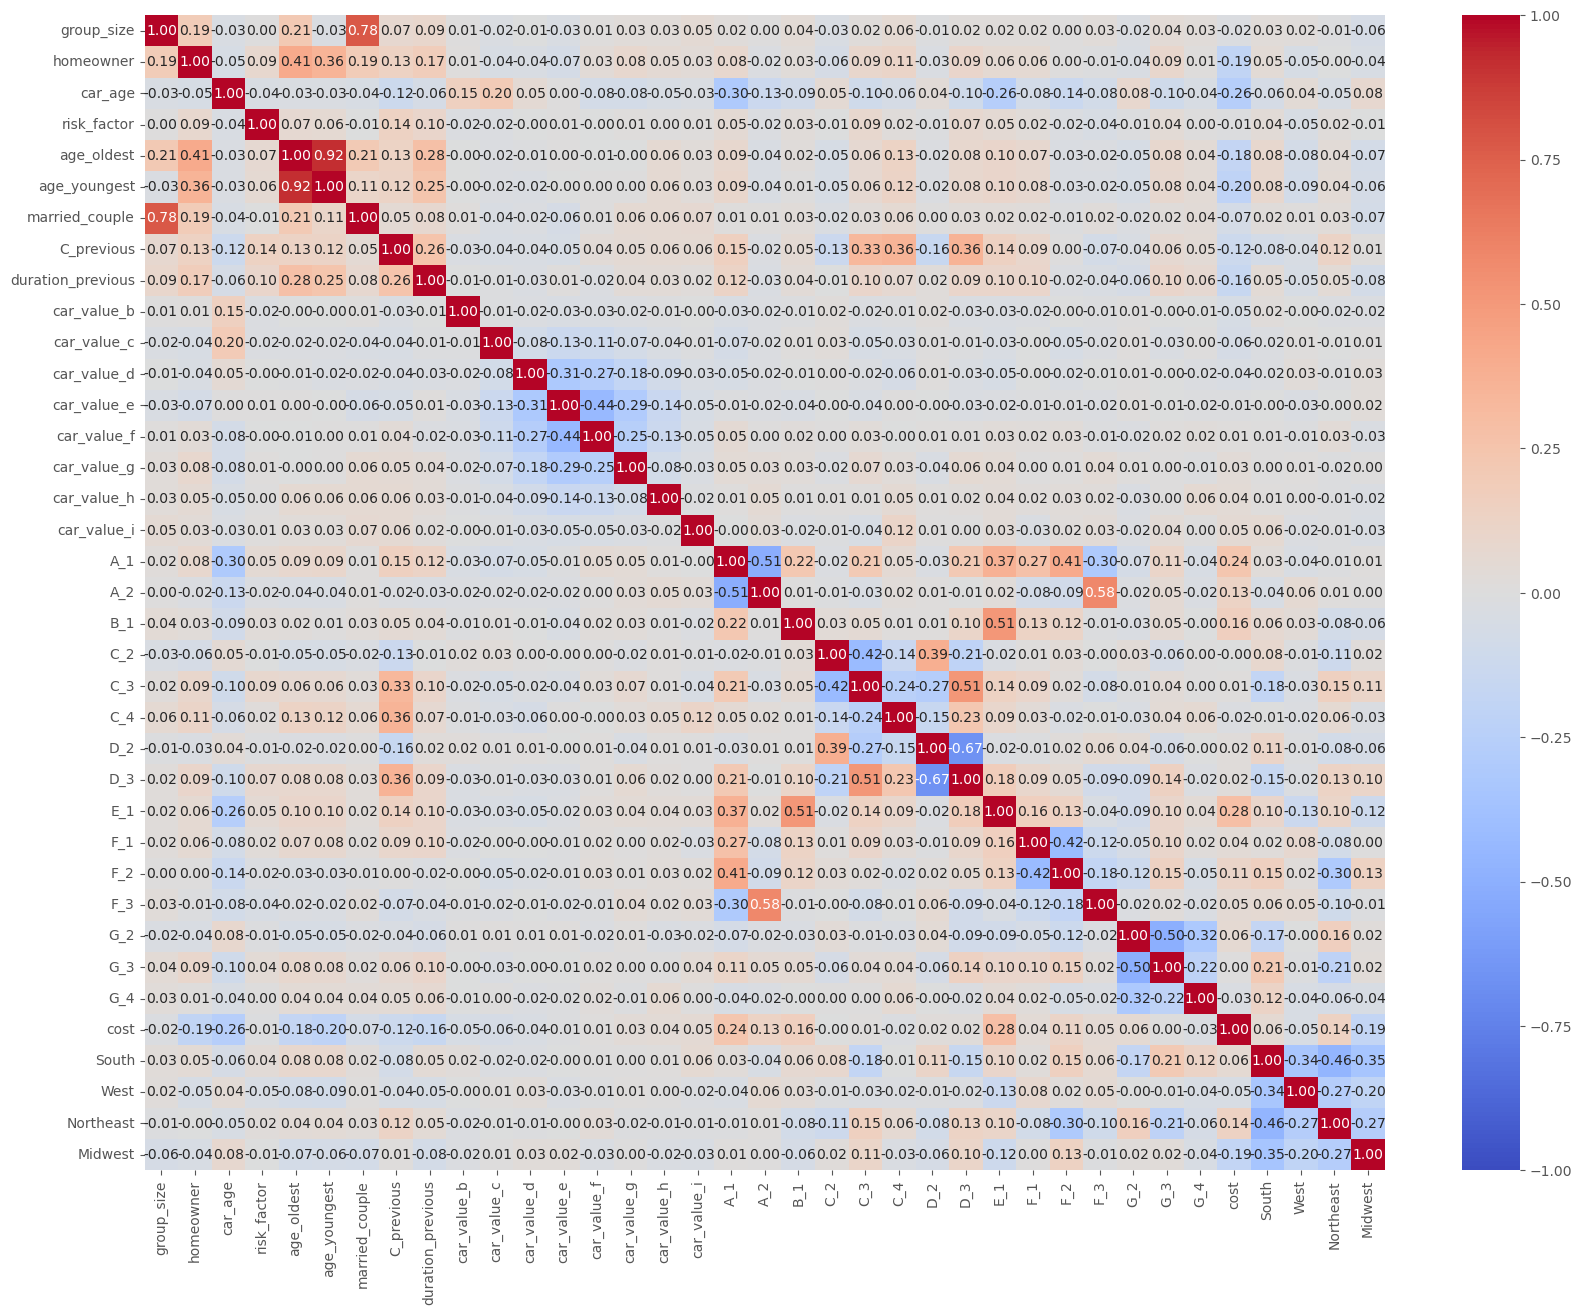

In [69]:
#Create a correlation matrix to observe correlation between numerical features
correlation_matrix = training_data_new[numerical_features].corr()

#visualize correlation matrix - easier to analyze 
plt.figure(figsize=(20, 15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.show()

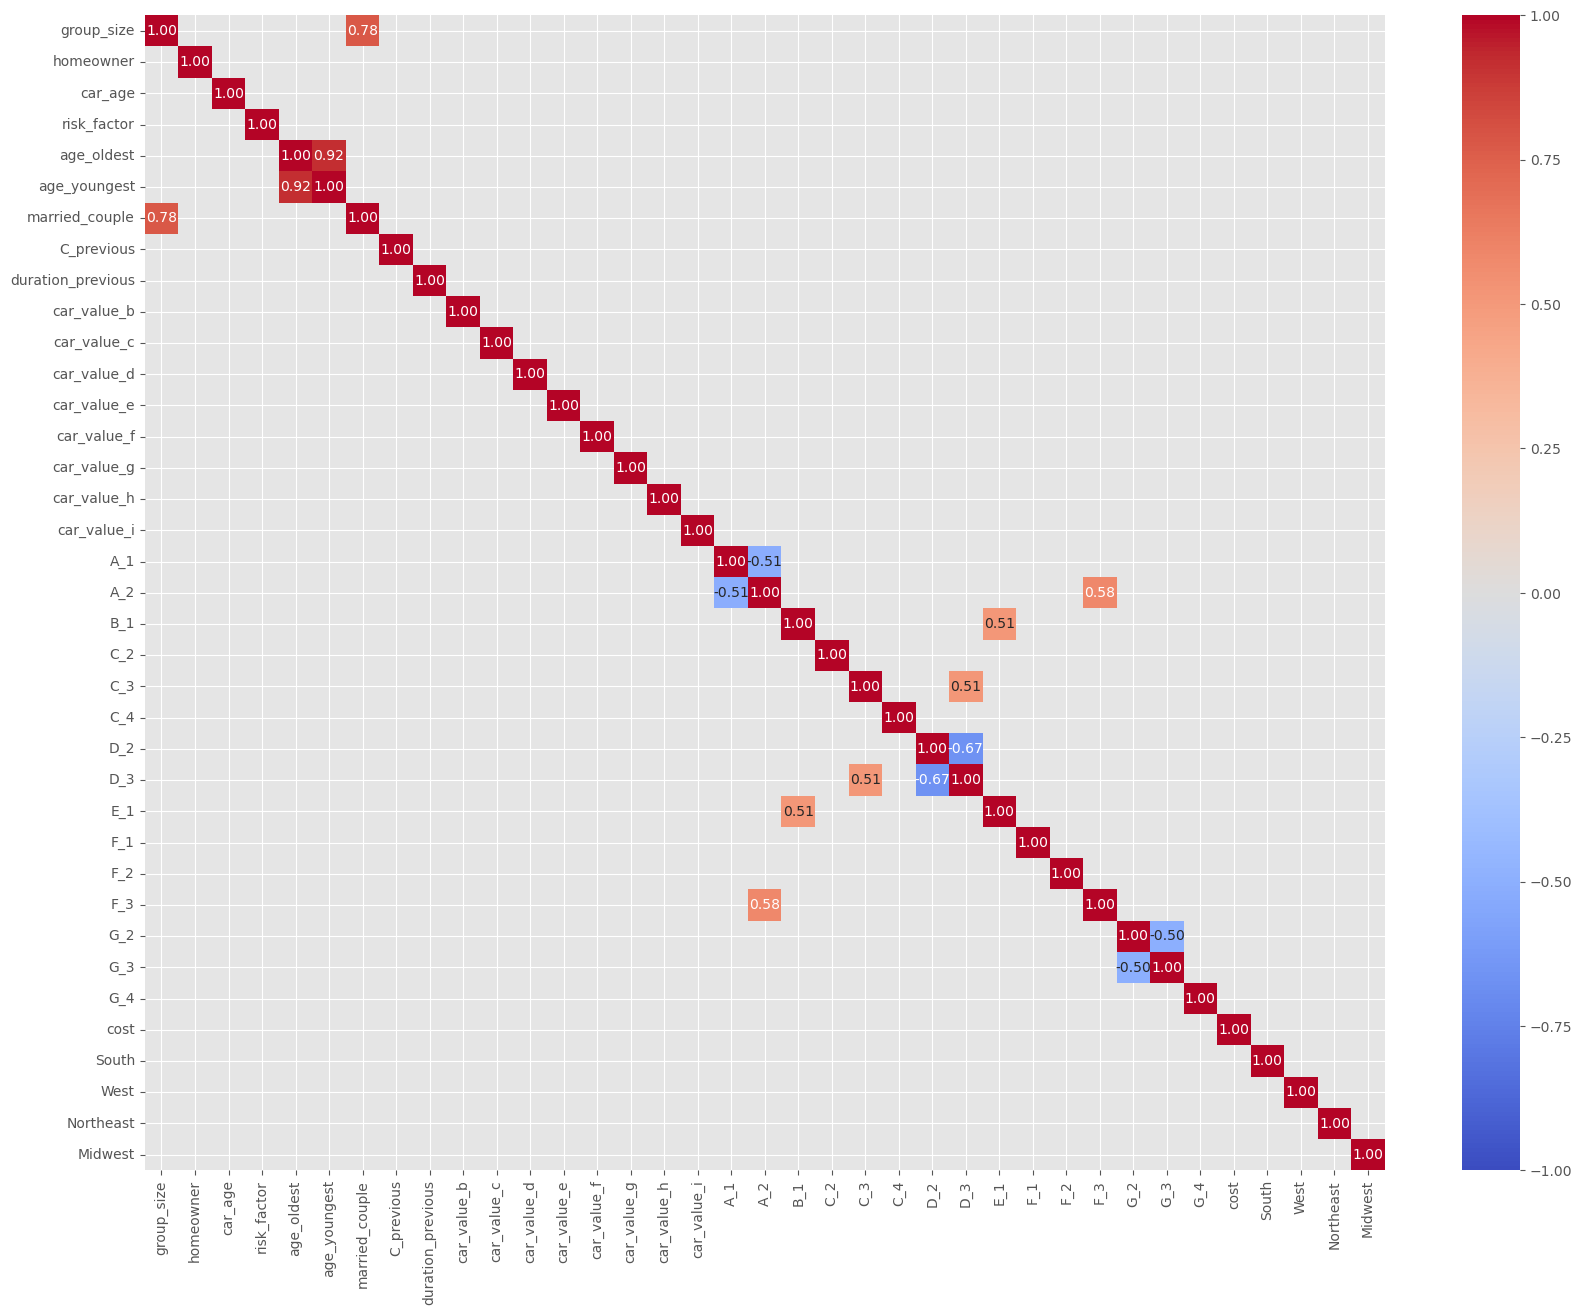

In [70]:
#Since there are so many variables - we will try to only look at ones with correlation above (absolute) 0.5
#We are only interested in very strong correlations and this will make them easier to see

filtered_correlation = correlation_matrix[abs(correlation_matrix) > 0.5]

plt.figure(figsize=(20, 15))  
sns.heatmap(filtered_correlation, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.show()

Multicollinearity occurs when two variables are highly correlated. For this exercise, I will consider highly correlated as having a correlation above the threshold of 0.75. From the above correlation matrix plot, we can observe that there are two pairs that have this high correlation - the relationship between age_youngest and age_oldest, as well as the relationship between group size and married couple.

----------

#### 8.3:

Refit `model_region` after dropping these redundant predictor(s); call this `model_region_no_oldest`.

**Answer.**

As described earlier, the multicollinear pairs is between the variables age_oldest/age_youngest and married couple/group size. We have already removed the 'group size' variable from the model due to it's insignificant p-value in an earlier step. Now, I will also remove the variable age_oldest from this following model. 

In [76]:
model_region_no_oldest = smf.ols(formula=('cost ~ homeowner+ risk_factor+ car_age + age_youngest+ married_couple+ C_previous+ duration_previous +' 
                                  'car_value_b + car_value_c + car_value_d + car_value_e + car_value_f + car_value_g +'
                                  'car_value_h+ car_value_i + A_1 + A_2 + B_1 + C_2 + C_3 + C_4 + E_1 + F_1 + F_2 + F_3 + G_2 + G_3 + G_4+ '
                                  'I(age_youngest **2) + I(car_age **2) + car_value_b *age_youngest + car_value_c *age_youngest +'
                                  'car_value_d *age_youngest + car_value_e *age_youngest + car_value_f *age_youngest + '
                                  'car_value_g *age_youngest + car_value_h *age_youngest + South + West + Northeast + Midwest'
                                 ),data = training_data_new).fit()
print(model_region_no_oldest.summary())

                            OLS Regression Results                            
Dep. Variable:                   cost   R-squared:                       0.376
Model:                            OLS   Adj. R-squared:                  0.373
Method:                 Least Squares   F-statistic:                     181.0
Date:                Fri, 07 Feb 2025   Prob (F-statistic):               0.00
Time:                        15:44:04   Log-Likelihood:                -62419.
No. Observations:               12386   AIC:                         1.249e+05
Df Residuals:                   12344   BIC:                         1.252e+05
Df Model:                          41                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

----------

#### 8.4

What would you do to diagnose the `model_region_no_oldest` fit? What does this diagnosis suggest to you? (Hint: try plotting the residuals in various ways.)

**Answer.**

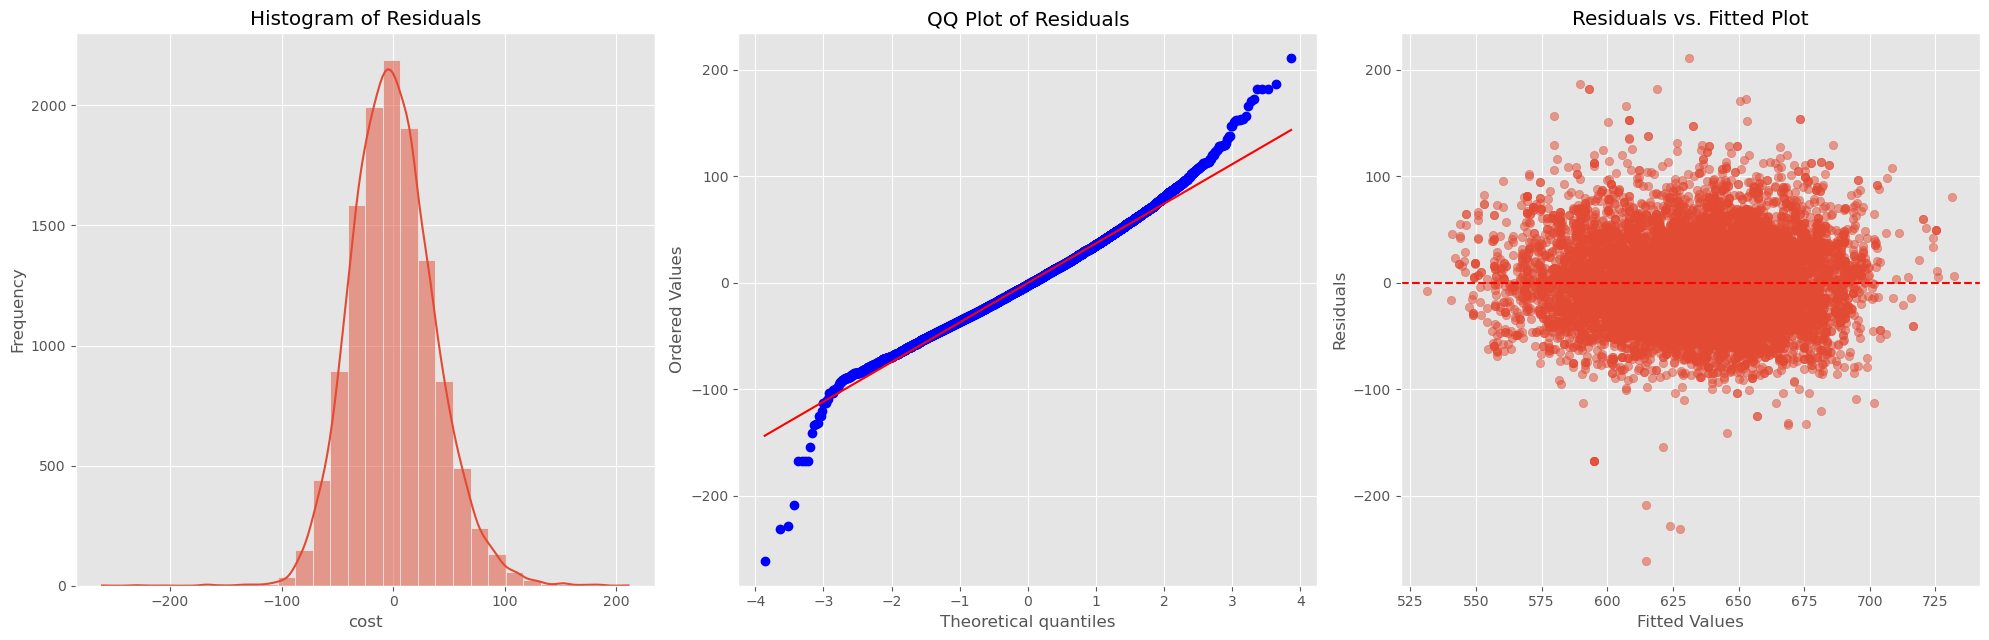

In [80]:
#obtaining residuals
residuals = model_region_no_oldest.resid
fitted_values = model_region_no_oldest.fittedvalues

fig, axes = plt.subplots (1,3, figsize = (20,6.5))

#Checking Normality 
sns.histplot(residuals, bins=30, kde=True, ax = axes[0])
axes[0].set_xlabel("cost")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Histogram of Residuals")

#observing QQ plot
stats.probplot(residuals, dist = "norm", plot = axes[1])
axes[1].set_title("QQ Plot of Residuals")

#Observing homoscedasticity
axes[2].scatter(fitted_values, residuals, alpha=0.5)
axes[2].axhline(y=0, color='red', linestyle='--')
axes[2].set_xlabel("Fitted Values")
axes[2].set_ylabel("Residuals")
axes[2].set_title("Residuals vs. Fitted Plot")

plt.tight_layout()
plt.show()

Above we have observed the residuals in the data in three different ways:
1. histogram with normal curve (left)
2. QQ plot (middle)
3. Scatterplot with normal line to observe homoscedasticity (right)

In the first diagram, it appears that the residuals mostly follow a normal distribution. 
The second plot does no entirely follow the normal line. Instead it implies that there are some outliers/heavy tails. 
The third plot, has mostly evenly distributed points which indicate homoscedasticity. This plot also indicate there are some outliers that should be addressed. 

Overall, we learned that the model we have made is not perfect. There are some adjustments we can make to our model to rectify the heavy tails of the residuals. This way, our model will make better predictions.

----------

### Exercise 9:

#### 9.1

Find the best Box-Cox transformation of `cost` used to fit `model_region_no_oldest`. What value do you get?

**Answer.**

In [85]:
cost,fitted_lambda = stats.boxcox(training_data_new['cost'])
round(fitted_lambda,2)  

0.49

The estimate of lambda is approximately 0.5, this suggests that we should apply a square-root transformation to the model.

----------

#### 9.2

Refit `model_region_no_oldest`, but now with the transformation as suggested by the Box-Cox. Call it `model_region_no_oldest_box_cox`.

**Answer.**

In [90]:
#Observing skewedness to determine which variables should be transformed
training_data_new[numerical_features].skew()

group_size            1.801522
homeowner            -0.123291
car_age               1.054456
risk_factor           0.332285
age_oldest            0.178883
age_youngest          0.308870
married_couple        1.450729
C_previous           -0.267860
duration_previous     0.717257
car_value_b          20.963441
car_value_c           5.374015
car_value_d           1.828114
car_value_e           0.697068
car_value_f           1.014814
car_value_g           2.025965
car_value_h           4.708562
car_value_i          13.190553
A_1                  -0.599505
A_2                   2.245099
B_1                   0.272177
C_2                   1.478400
C_3                   0.346478
C_4                   3.203312
D_2                   1.230534
D_3                  -0.365092
E_1                   0.303152
F_1                   1.395799
F_2                   0.426684
F_3                   4.154732
G_2                   0.305827
G_3                   1.125045
G_4                   2.310293
cost    

Above, we have found the level of skewedness for each variable. I will transform variables that have a skewness level greater than 1 as this indicates they are highly skewed. Thus, I will be apply the square root transformation on the following variables:
- 'car_age'
- 'married_couple'
- 'car_value_b'
- 'car_value_c'
- 'car_value_d'
- 'car_value_f'
- 'car_value_g'
- 'car_value_h'
- 'car_value_i'
- 'A_2'
- 'C_2'
- 'C_4'
- F_1'
- 'F_3'
- 'G_3'
- 'G_4'
- 'West'
- 'Northeast'
- 'Midwest'
  
These are the variables that have a skewed level greater than 1 and are in the model. 

In [92]:
model_region_no_oldest_box_cox = smf.ols(formula=('np.sqrt(cost) ~ homeowner+ risk_factor+ np.sqrt(car_age) + age_youngest+ np.sqrt(married_couple) + C_previous+' 
                                  'duration_previous + np.sqrt(car_value_b) + np.sqrt(car_value_c) + np.sqrt(car_value_d) + car_value_e + np.sqrt(car_value_f) +'
                                  'np.sqrt(car_value_g) + np.sqrt(car_value_h) + np.sqrt(car_value_i) + A_1 + np.sqrt(A_2) + B_1 + np.sqrt(C_2) + C_3 + np.sqrt(C_4)+ '
                                  'E_1 + np.sqrt(F_1) + F_2 + np.sqrt(F_3) + G_2 + np.sqrt(G_3) + np.sqrt(G_4)+ I(age_youngest **2) + I(car_age **2) + car_value_b *age_youngest+' 
                                  'car_value_c *age_youngest + car_value_d *age_youngest + car_value_e *age_youngest + car_value_f *age_youngest + '
                                  'car_value_g *age_youngest + car_value_h *age_youngest + South + np.sqrt(West) + np.sqrt(Northeast) + np.sqrt(Midwest)'
                                 ),data = training_data_new).fit()
print(model_region_no_oldest_box_cox.summary())

                            OLS Regression Results                            
Dep. Variable:          np.sqrt(cost)   R-squared:                       0.378
Model:                            OLS   Adj. R-squared:                  0.376
Method:                 Least Squares   F-statistic:                     183.2
Date:                Fri, 07 Feb 2025   Prob (F-statistic):               0.00
Time:                        15:44:05   Log-Likelihood:                -13847.
No. Observations:               12386   AIC:                         2.778e+04
Df Residuals:                   12344   BIC:                         2.809e+04
Df Model:                          41                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

----------

## Conclusion

In this, you practiced creating linear models using `statsmodels` and iteratively trimming the input variables to go from including all the variables in the dataset to using only the most relevant variables. You excluded those variables that were statistically insignificant and removed those that had high correlation. Finally, we performed some feature engineering in an attempt to remove some tail behavior that deviates from the normal distribution to better fit our linear model. In the end, we had a very minimal model that contained variables that other insurance companies use to charge premiums that gave us insight on how we can better serve a niche population. 